In [1]:
!pip install pyspark

from pyspark.sql import SparkSession

import pandas as pd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.2-py2.py3-none-any.whl size=317812365 sha256=3b145ae0d0f6c5569c0b53944ba3b28ef0e32f3a24440a351feb3373a99d7f10
  Stored in directory: /root/.cache/pip/wheels/34/34/bd/03944534c44b677cd5859f248090daa9fb27b3c8f8e5f49574
Successfully built pyspark


In [2]:
spark = SparkSession.builder.appName('test').getOrCreate()

In [3]:
data = {'Employee':['vamshi','camila'],'salary':[100,200]}
df_pandas = pd.DataFrame(data)
df_pandas.head()



,Employee,salary
0,vamshi,100
1,camila,200


In [4]:
df = spark.createDataFrame(data=df_pandas)
df.show()



+--------+------+
|Employee|salary|
+--------+------+
|  vamshi|   100|
|  camila|   200|
+--------+------+



In [5]:
df = spark.createDataFrame(data=list(zip(tuple(data['Employee']),tuple(data['salary']))),schema=['Employee','salary'])
df.show()

+--------+------+
|Employee|salary|
+--------+------+
|  vamshi|   100|
|  camila|   200|
+--------+------+



In [6]:
from pyspark.sql.types import StructType , StructField,StringType,IntegerType,LongType,FloatType,DoubleType

In [7]:
Schema = StructType([StructField('Employee',StringType(),nullable=False),StructField('salary',IntegerType(),nullable=False)])
df = spark.createDataFrame(data=list(zip(tuple(data['Employee']),tuple(data['salary']))),schema=Schema)
df.show()

+--------+------+
|Employee|salary|
+--------+------+
|  vamshi|   100|
|  camila|   200|
+--------+------+



In [8]:
df.printSchema()

root
 |-- Employee: string (nullable = false)
 |-- salary: integer (nullable = false)



# **Modes in pyspark**

In [9]:
df_housing = spark.read.format('csv').option('header','true').option('inferSchema','true').load('/content/sample_data/california_housing_train.csv')
df_housing.show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|  -114.31|   34.19|              15.0|     5612.0|        1283.0|    1015.0|     472.0|       1.4936|           66900.0|
|  -114.47|    34.4|              19.0|     7650.0|        1901.0|    1129.0|     463.0|         1.82|           80100.0|
|  -114.56|   33.69|              17.0|      720.0|         174.0|     333.0|     117.0|       1.6509|           85700.0|
|  -114.57|   33.64|              14.0|     1501.0|         337.0|     515.0|     226.0|       3.1917|           73400.0|
|  -114.57|   33.57|              20.0|     1454.0|         326.0|     624.0|     262.0|        1.925|           65500.0|
|  -114.58|   33.63|    

In [10]:
df_housing.repartition(3).write.mode('overwrite').format('csv').option('header','true').save('/content/sample_data/output')

In [11]:
df_housing = spark.read.format('csv').option('header','true').option('inferSchema','true').load('/content/sample_data/output')

In [12]:
df_housing.count()

17000

In [13]:
df_housing.repartition(3).write.mode('append').format('csv').option('header','true').save('/content/sample_data/output')

In [14]:
df_housing = spark.read.format('csv').option('header','true').option('inferSchema','true').load('/content/sample_data/output')

In [15]:
df_housing.count()

34000

# Manuplating columns

In [16]:
from pyspark.sql.functions import col,lit

In [17]:
df_housing.show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|  -118.21|   34.04|              47.0|     1306.0|         391.0|    1499.0|     346.0|       2.2788|          139600.0|
|  -120.76|    38.6|              14.0|     2925.0|         625.0|    1226.0|     437.0|       2.5865|          133800.0|
|  -118.55|   34.23|              25.0|     4409.0|        1018.0|    4579.0|    1010.0|       2.8727|          245100.0|
|  -122.25|   37.86|              52.0|     4048.0|         663.0|    1316.0|     590.0|       5.3794|          376900.0|
|  -122.29|    38.3|              52.0|      144.0|          54.0|      89.0|      48.0|       1.0096|          162500.0|
|  -117.25|   32.72|    

In [18]:
df_housing.printSchema()

root
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- housing_median_age: double (nullable = true)
 |-- total_rooms: double (nullable = true)
 |-- total_bedrooms: double (nullable = true)
 |-- population: double (nullable = true)
 |-- households: double (nullable = true)
 |-- median_income: double (nullable = true)
 |-- median_house_value: double (nullable = true)



In [19]:
df_housing_modified  = df_housing.withColumn('total_bedrooms_modified',col('total_bedrooms').cast('int')*2)

In [20]:
df_housing_modified.columns

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'total_bedrooms_modified']

In [21]:
df_housing_modified["total_bedrooms_modified",'total_bedrooms'].show()

+-----------------------+--------------+
|total_bedrooms_modified|total_bedrooms|
+-----------------------+--------------+
|                    782|         391.0|
|                   1250|         625.0|
|                   2036|        1018.0|
|                   1326|         663.0|
|                    108|          54.0|
|                    900|         450.0|
|                    520|         260.0|
|                   1094|         547.0|
|                   1186|         593.0|
|                   1000|         500.0|
|                   1138|         569.0|
|                    686|         343.0|
|                   1766|         883.0|
|                    322|         161.0|
|                   1250|         625.0|
|                    620|         310.0|
|                    902|         451.0|
|                    816|         408.0|
|                   2006|        1003.0|
|                    384|         192.0|
+-----------------------+--------------+
only showing top

In [22]:
df_housing_modified.withColumn('country',lit('India')).select('country','total_bedrooms_modified').show()

+-------+-----------------------+
|country|total_bedrooms_modified|
+-------+-----------------------+
|  India|                    782|
|  India|                   1250|
|  India|                   2036|
|  India|                   1326|
|  India|                    108|
|  India|                    900|
|  India|                    520|
|  India|                   1094|
|  India|                   1186|
|  India|                   1000|
|  India|                   1138|
|  India|                    686|
|  India|                   1766|
|  India|                    322|
|  India|                   1250|
|  India|                    620|
|  India|                    902|
|  India|                    816|
|  India|                   2006|
|  India|                    384|
+-------+-----------------------+
only showing top 20 rows



# ArrayType

in struct field make sure you pass Arraytype(Integertype())

In [23]:
from pyspark.sql.functions import array

In [24]:
df = df_housing.select(array('longitude','latitude').alias('coordinates'))

In [25]:
df.show()

+----------------+
|     coordinates|
+----------------+
|[-118.21, 34.04]|
| [-120.76, 38.6]|
|[-118.55, 34.23]|
|[-122.25, 37.86]|
| [-122.29, 38.3]|
|[-117.25, 32.72]|
| [-118.22, 33.9]|
|[-118.58, 34.15]|
|[-122.06, 37.34]|
| [-117.1, 32.74]|
|[-121.92, 37.27]|
|[-117.89, 33.77]|
|[-118.61, 34.38]|
|[-121.92, 36.62]|
|  [-116.2, 33.7]|
|[-118.23, 33.98]|
|[-118.44, 33.88]|
|[-118.16, 33.91]|
|[-117.85, 33.74]|
|[-117.94, 33.83]|
+----------------+
only showing top 20 rows



In [26]:
df_1 = df.withColumn('longitude',col('coordinates')[0].cast(IntegerType())*2)

In [27]:
df_1.columns

['coordinates', 'longitude']

In [28]:
df_1.show()

+----------------+---------+
|     coordinates|longitude|
+----------------+---------+
|[-118.21, 34.04]|     -236|
| [-120.76, 38.6]|     -240|
|[-118.55, 34.23]|     -236|
|[-122.25, 37.86]|     -244|
| [-122.29, 38.3]|     -244|
|[-117.25, 32.72]|     -234|
| [-118.22, 33.9]|     -236|
|[-118.58, 34.15]|     -236|
|[-122.06, 37.34]|     -244|
| [-117.1, 32.74]|     -234|
|[-121.92, 37.27]|     -242|
|[-117.89, 33.77]|     -234|
|[-118.61, 34.38]|     -236|
|[-121.92, 36.62]|     -242|
|  [-116.2, 33.7]|     -232|
|[-118.23, 33.98]|     -236|
|[-118.44, 33.88]|     -236|
|[-118.16, 33.91]|     -236|
|[-117.85, 33.74]|     -234|
|[-117.94, 33.83]|     -234|
+----------------+---------+
only showing top 20 rows



In [29]:
from pyspark.sql.functions import to_json,struct

In [30]:
df_housing_modified.printSchema()

root
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- housing_median_age: double (nullable = true)
 |-- total_rooms: double (nullable = true)
 |-- total_bedrooms: double (nullable = true)
 |-- population: double (nullable = true)
 |-- households: double (nullable = true)
 |-- median_income: double (nullable = true)
 |-- median_house_value: double (nullable = true)
 |-- total_bedrooms_modified: integer (nullable = true)



In [31]:
df_test = df_housing.withColumn('mowa',struct('longitude','latitude'))

In [32]:
df_test.printSchema()

root
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- housing_median_age: double (nullable = true)
 |-- total_rooms: double (nullable = true)
 |-- total_bedrooms: double (nullable = true)
 |-- population: double (nullable = true)
 |-- households: double (nullable = true)
 |-- median_income: double (nullable = true)
 |-- median_house_value: double (nullable = true)
 |-- mowa: struct (nullable = false)
 |    |-- longitude: double (nullable = true)
 |    |-- latitude: double (nullable = true)



In [33]:
df_test = df_test.withColumn('mowa1',to_json(col('mowa')))

In [34]:
df_test.show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+----------------+--------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|            mowa|               mowa1|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+----------------+--------------------+
|  -118.21|   34.04|              47.0|     1306.0|         391.0|    1499.0|     346.0|       2.2788|          139600.0|{-118.21, 34.04}|{"longitude":-118...|
|  -120.76|    38.6|              14.0|     2925.0|         625.0|    1226.0|     437.0|       2.5865|          133800.0| {-120.76, 38.6}|{"longitude":-120...|
|  -118.55|   34.23|              25.0|     4409.0|        1018.0|    4579.0|    1010.0|       2.8727|          245100.0|{-118.55, 34.23}|{"longitude":-118...|
|  -122.25|   37.86|              52.0| 

In [35]:
df_test = df_test.drop('longitude')
df_test = df_test.drop('latitude')

In [36]:
df_test = df_test.withColumn('longi',col('mowa.longitude'))

In [37]:
df_test.show()

+------------------+-----------+--------------+----------+----------+-------------+------------------+----------------+--------------------+-------+
|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|            mowa|               mowa1|  longi|
+------------------+-----------+--------------+----------+----------+-------------+------------------+----------------+--------------------+-------+
|              47.0|     1306.0|         391.0|    1499.0|     346.0|       2.2788|          139600.0|{-118.21, 34.04}|{"longitude":-118...|-118.21|
|              14.0|     2925.0|         625.0|    1226.0|     437.0|       2.5865|          133800.0| {-120.76, 38.6}|{"longitude":-120...|-120.76|
|              25.0|     4409.0|        1018.0|    4579.0|    1010.0|       2.8727|          245100.0|{-118.55, 34.23}|{"longitude":-118...|-118.55|
|              52.0|     4048.0|         663.0|    1316.0|     590.0|       5.3794|          376900.0|{-12

In [38]:
df_test.select('mowa','mowa1','longi').show()

+----------------+--------------------+-------+
|            mowa|               mowa1|  longi|
+----------------+--------------------+-------+
|{-118.21, 34.04}|{"longitude":-118...|-118.21|
| {-120.76, 38.6}|{"longitude":-120...|-120.76|
|{-118.55, 34.23}|{"longitude":-118...|-118.55|
|{-122.25, 37.86}|{"longitude":-122...|-122.25|
| {-122.29, 38.3}|{"longitude":-122...|-122.29|
|{-117.25, 32.72}|{"longitude":-117...|-117.25|
| {-118.22, 33.9}|{"longitude":-118...|-118.22|
|{-118.58, 34.15}|{"longitude":-118...|-118.58|
|{-122.06, 37.34}|{"longitude":-122...|-122.06|
| {-117.1, 32.74}|{"longitude":-117...| -117.1|
|{-121.92, 37.27}|{"longitude":-121...|-121.92|
|{-117.89, 33.77}|{"longitude":-117...|-117.89|
|{-118.61, 34.38}|{"longitude":-118...|-118.61|
|{-121.92, 36.62}|{"longitude":-121...|-121.92|
|  {-116.2, 33.7}|{"longitude":-116...| -116.2|
|{-118.23, 33.98}|{"longitude":-118...|-118.23|
|{-118.44, 33.88}|{"longitude":-118...|-118.44|
|{-118.16, 33.91}|{"longitude":-118...|-

In [39]:
df_test.select('mowa','mowa1','longi').write.mode('overwrite').format('json').save('/content/sample_data/output2.json')

In [40]:
from pyspark.sql.types import MapType,DoubleType

In [41]:
help(MapType)

Help on class MapType in module pyspark.sql.types:

class MapType(DataType)
 |  MapType(keyType: pyspark.sql.types.DataType, valueType: pyspark.sql.types.DataType, valueContainsNull: bool = True)
 |  
 |  Map data type.
 |  
 |  Parameters
 |  ----------
 |  keyType : :class:`DataType`
 |      :class:`DataType` of the keys in the map.
 |  valueType : :class:`DataType`
 |      :class:`DataType` of the values in the map.
 |  valueContainsNull : bool, optional
 |      indicates whether values can contain null (None) values.
 |  
 |  Notes
 |  -----
 |  Keys in a map data type are not allowed to be null (None).
 |  
 |  Examples
 |  --------
 |  >>> from pyspark.sql.types import IntegerType, FloatType, MapType, StringType
 |  
 |  The below example demonstrates how to create class:`MapType`:
 |  
 |  >>> map_type = MapType(StringType(), IntegerType())
 |  
 |  The values of the map can contain null (``None``) values by default:
 |  
 |  >>> (MapType(StringType(), IntegerType())
 |  ...    

In [42]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, MapType, FloatType

schema = StructType([
    StructField('longi', FloatType(),True),
    StructField('mowa1', StringType()),  # Specify the data type for 'mowa'
    StructField('mowa', MapType(StringType(), FloatType()))  # Wrap MapType within a StructField
])

In [43]:
dfsample = spark.read.format('json').schema(schema).load('/content/sample_data/output2.json')

In [44]:
dfsample.printSchema()

root
 |-- longi: float (nullable = true)
 |-- mowa1: string (nullable = true)
 |-- mowa: map (nullable = true)
 |    |-- key: string
 |    |-- value: float (valueContainsNull = true)



In [45]:
dfsample.show()

+-------+--------------------+--------------------+
|  longi|               mowa1|                mowa|
+-------+--------------------+--------------------+
|-118.33|{"longitude":-118...|{longitude -> -11...|
|-118.55|{"longitude":-118...|{longitude -> -11...|
|-117.59|{"longitude":-117...|{longitude -> -11...|
|-117.25|{"longitude":-117...|{longitude -> -11...|
|-122.43|{"longitude":-122...|{longitude -> -12...|
|-122.06|{"longitude":-122...|{longitude -> -12...|
|-122.35|{"longitude":-122...|{longitude -> -12...|
|-117.89|{"longitude":-117...|{longitude -> -11...|
|-117.91|{"longitude":-117...|{longitude -> -11...|
| -116.2|{"longitude":-116...|{longitude -> -11...|
|-118.25|{"longitude":-118...|{longitude -> -11...|
|-118.16|{"longitude":-118...|{longitude -> -11...|
|-120.98|{"longitude":-120...|{longitude -> -12...|
|-117.88|{"longitude":-117...|{longitude -> -11...|
|-118.04|{"longitude":-118...|{longitude -> -11...|
|-118.11|{"longitude":-118...|{longitude -> -11...|
|-118.29|{"l

In [46]:
dfsample.select(col('mowa.longitude')).show()

+---------+
|longitude|
+---------+
|  -118.33|
|  -118.55|
|  -117.59|
|  -117.25|
|  -122.43|
|  -122.06|
|  -122.35|
|  -117.89|
|  -117.91|
|   -116.2|
|  -118.25|
|  -118.16|
|  -120.98|
|  -117.88|
|  -118.04|
|  -118.11|
|  -118.29|
|   -118.3|
|  -121.06|
|  -122.72|
+---------+
only showing top 20 rows



In [47]:
from pyspark.sql.functions import from_json

In [48]:
dfsample.select('mowa1').show(truncate=False)

+--------------------------------------+
|mowa1                                 |
+--------------------------------------+
|{"longitude":-118.33,"latitude":34.0} |
|{"longitude":-118.55,"latitude":34.23}|
|{"longitude":-117.59,"latitude":34.03}|
|{"longitude":-117.25,"latitude":32.72}|
|{"longitude":-122.43,"latitude":37.8} |
|{"longitude":-122.06,"latitude":37.34}|
|{"longitude":-122.35,"latitude":37.58}|
|{"longitude":-117.89,"latitude":33.77}|
|{"longitude":-117.91,"latitude":33.77}|
|{"longitude":-116.2,"latitude":33.7}  |
|{"longitude":-118.25,"latitude":33.96}|
|{"longitude":-118.16,"latitude":33.91}|
|{"longitude":-120.98,"latitude":37.66}|
|{"longitude":-117.88,"latitude":33.84}|
|{"longitude":-118.04,"latitude":33.87}|
|{"longitude":-118.11,"latitude":34.15}|
|{"longitude":-118.29,"latitude":33.84}|
|{"longitude":-118.3,"latitude":34.07} |
|{"longitude":-121.06,"latitude":39.04}|
|{"longitude":-122.72,"latitude":38.46}|
+--------------------------------------+
only showing top

In [49]:
df_test = dfsample.select(from_json('mowa1',"MAP<STRING,DOUBLE>"))

In [50]:
df_test.printSchema()

root
 |-- entries: map (nullable = true)
 |    |-- key: string
 |    |-- value: double (valueContainsNull = true)



In [51]:
df_test.show(truncate=False)

+-----------------------------------------+
|entries                                  |
+-----------------------------------------+
|{longitude -> -118.33, latitude -> 34.0} |
|{longitude -> -118.55, latitude -> 34.23}|
|{longitude -> -117.59, latitude -> 34.03}|
|{longitude -> -117.25, latitude -> 32.72}|
|{longitude -> -122.43, latitude -> 37.8} |
|{longitude -> -122.06, latitude -> 37.34}|
|{longitude -> -122.35, latitude -> 37.58}|
|{longitude -> -117.89, latitude -> 33.77}|
|{longitude -> -117.91, latitude -> 33.77}|
|{longitude -> -116.2, latitude -> 33.7}  |
|{longitude -> -118.25, latitude -> 33.96}|
|{longitude -> -118.16, latitude -> 33.91}|
|{longitude -> -120.98, latitude -> 37.66}|
|{longitude -> -117.88, latitude -> 33.84}|
|{longitude -> -118.04, latitude -> 33.87}|
|{longitude -> -118.11, latitude -> 34.15}|
|{longitude -> -118.29, latitude -> 33.84}|
|{longitude -> -118.3, latitude -> 34.07} |
|{longitude -> -121.06, latitude -> 39.04}|
|{longitude -> -122.72, latitude

# MAPS

In [52]:
df_test.show()

+--------------------+
|             entries|
+--------------------+
|{longitude -> -11...|
|{longitude -> -11...|
|{longitude -> -11...|
|{longitude -> -11...|
|{longitude -> -12...|
|{longitude -> -12...|
|{longitude -> -12...|
|{longitude -> -11...|
|{longitude -> -11...|
|{longitude -> -11...|
|{longitude -> -11...|
|{longitude -> -11...|
|{longitude -> -12...|
|{longitude -> -11...|
|{longitude -> -11...|
|{longitude -> -11...|
|{longitude -> -11...|
|{longitude -> -11...|
|{longitude -> -12...|
|{longitude -> -12...|
+--------------------+
only showing top 20 rows



In [53]:
df_test.columns

['entries']

In [54]:
df_test.select(col('entries.longitude')).show()

+---------+
|longitude|
+---------+
|  -118.33|
|  -118.55|
|  -117.59|
|  -117.25|
|  -122.43|
|  -122.06|
|  -122.35|
|  -117.89|
|  -117.91|
|   -116.2|
|  -118.25|
|  -118.16|
|  -120.98|
|  -117.88|
|  -118.04|
|  -118.11|
|  -118.29|
|   -118.3|
|  -121.06|
|  -122.72|
+---------+
only showing top 20 rows



In [55]:
from pyspark.sql.functions import explode

In [56]:
df_test.printSchema()

root
 |-- entries: map (nullable = true)
 |    |-- key: string
 |    |-- value: double (valueContainsNull = true)



In [57]:
df_test.select(col('*'),explode(df_test.entries)).show()

+--------------------+---------+-------+
|             entries|      key|  value|
+--------------------+---------+-------+
|{longitude -> -11...|longitude|-118.33|
|{longitude -> -11...| latitude|   34.0|
|{longitude -> -11...|longitude|-118.55|
|{longitude -> -11...| latitude|  34.23|
|{longitude -> -11...|longitude|-117.59|
|{longitude -> -11...| latitude|  34.03|
|{longitude -> -11...|longitude|-117.25|
|{longitude -> -11...| latitude|  32.72|
|{longitude -> -12...|longitude|-122.43|
|{longitude -> -12...| latitude|   37.8|
|{longitude -> -12...|longitude|-122.06|
|{longitude -> -12...| latitude|  37.34|
|{longitude -> -12...|longitude|-122.35|
|{longitude -> -12...| latitude|  37.58|
|{longitude -> -11...|longitude|-117.89|
|{longitude -> -11...| latitude|  33.77|
|{longitude -> -11...|longitude|-117.91|
|{longitude -> -11...| latitude|  33.77|
|{longitude -> -11...|longitude| -116.2|
|{longitude -> -11...| latitude|   33.7|
+--------------------+---------+-------+
only showing top

In [58]:
from pyspark.sql.functions import map_keys,map_values

In [59]:
df_test.select(col('*'),map_keys(df_test.entries)).show()

+--------------------+--------------------+
|             entries|   map_keys(entries)|
+--------------------+--------------------+
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -12...|[longitude, latit...|
|{longitude -> -12...|[longitude, latit...|
|{longitude -> -12...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -12...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -11...|[longitude, latit...|
|{longitude -> -12...|[longitude, latit...|
|{longitude -> -12...|[longitude

In [60]:
print(df_test.select(col('*'),map_keys(df_test.entries)).count())
df_test.select(col('*'),explode(df_test.entries)).count()

34000


68000

# when -- > used on top of the column similar to CASE clause in SQL

In [61]:
df_test.show(truncate=False)

+-----------------------------------------+
|entries                                  |
+-----------------------------------------+
|{longitude -> -118.33, latitude -> 34.0} |
|{longitude -> -118.55, latitude -> 34.23}|
|{longitude -> -117.59, latitude -> 34.03}|
|{longitude -> -117.25, latitude -> 32.72}|
|{longitude -> -122.43, latitude -> 37.8} |
|{longitude -> -122.06, latitude -> 37.34}|
|{longitude -> -122.35, latitude -> 37.58}|
|{longitude -> -117.89, latitude -> 33.77}|
|{longitude -> -117.91, latitude -> 33.77}|
|{longitude -> -116.2, latitude -> 33.7}  |
|{longitude -> -118.25, latitude -> 33.96}|
|{longitude -> -118.16, latitude -> 33.91}|
|{longitude -> -120.98, latitude -> 37.66}|
|{longitude -> -117.88, latitude -> 33.84}|
|{longitude -> -118.04, latitude -> 33.87}|
|{longitude -> -118.11, latitude -> 34.15}|
|{longitude -> -118.29, latitude -> 33.84}|
|{longitude -> -118.3, latitude -> 34.07} |
|{longitude -> -121.06, latitude -> 39.04}|
|{longitude -> -122.72, latitude

In [62]:
from pyspark.sql.functions import when

In [63]:
df_test.select(col('entries.longitude'),when(col('entries.longitude') < -118.0,115.0).otherwise(0).alias('lati')).show()

+---------+-----+
|longitude| lati|
+---------+-----+
|  -118.33|115.0|
|  -118.55|115.0|
|  -117.59|  0.0|
|  -117.25|  0.0|
|  -122.43|115.0|
|  -122.06|115.0|
|  -122.35|115.0|
|  -117.89|  0.0|
|  -117.91|  0.0|
|   -116.2|  0.0|
|  -118.25|115.0|
|  -118.16|115.0|
|  -120.98|115.0|
|  -117.88|  0.0|
|  -118.04|115.0|
|  -118.11|115.0|
|  -118.29|115.0|
|   -118.3|115.0|
|  -121.06|115.0|
|  -122.72|115.0|
+---------+-----+
only showing top 20 rows



In [64]:
df_test.select(col('entries.longitude'),when(col('entries.longitude')< -118.0,115.0).alias('lati')).count()

34000

In [65]:
df_test.count()

34000

# Where & Filter both are same !!

In [66]:
df_test.where(col('entries.longitude') < -118.0).alias('lati').show(truncate=False)

+-----------------------------------------+
|entries                                  |
+-----------------------------------------+
|{longitude -> -118.33, latitude -> 34.0} |
|{longitude -> -118.55, latitude -> 34.23}|
|{longitude -> -122.43, latitude -> 37.8} |
|{longitude -> -122.06, latitude -> 37.34}|
|{longitude -> -122.35, latitude -> 37.58}|
|{longitude -> -118.25, latitude -> 33.96}|
|{longitude -> -118.16, latitude -> 33.91}|
|{longitude -> -120.98, latitude -> 37.66}|
|{longitude -> -118.04, latitude -> 33.87}|
|{longitude -> -118.11, latitude -> 34.15}|
|{longitude -> -118.29, latitude -> 33.84}|
|{longitude -> -118.3, latitude -> 34.07} |
|{longitude -> -121.06, latitude -> 39.04}|
|{longitude -> -122.72, latitude -> 38.46}|
|{longitude -> -118.32, latitude -> 33.88}|
|{longitude -> -121.23, latitude -> 37.98}|
|{longitude -> -122.47, latitude -> 37.95}|
|{longitude -> -123.1, latitude -> 38.79} |
|{longitude -> -124.21, latitude -> 41.77}|
|{longitude -> -122.21, latitude

In [67]:
df_test.where(col('entries.longitude') < -118.0).alias('lati').count()

25454

# GroupBy

In [68]:
df_housing.show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|  -118.21|   34.04|              47.0|     1306.0|         391.0|    1499.0|     346.0|       2.2788|          139600.0|
|  -120.76|    38.6|              14.0|     2925.0|         625.0|    1226.0|     437.0|       2.5865|          133800.0|
|  -118.55|   34.23|              25.0|     4409.0|        1018.0|    4579.0|    1010.0|       2.8727|          245100.0|
|  -122.25|   37.86|              52.0|     4048.0|         663.0|    1316.0|     590.0|       5.3794|          376900.0|
|  -122.29|    38.3|              52.0|      144.0|          54.0|      89.0|      48.0|       1.0096|          162500.0|
|  -117.25|   32.72|    

In [69]:
df = spark.read.format('csv').option('header','true').option('inferSchema','true').load('/content/sample_data/california_housing_train.csv')

In [70]:
df.columns

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [71]:
df.select(col('*') , when(df['housing_median_age'] > 15.0 , 'old').when(df['housing_median_age'] > 20.0 & df['housing_median_age'] <= 15.0 ,'veryOld')).show()

Py4JError: An error occurred while calling o271.and. Trace:
py4j.Py4JException: Method and([class java.lang.Double]) does not exist
	at py4j.reflection.ReflectionEngine.getMethod(ReflectionEngine.java:321)
	at py4j.reflection.ReflectionEngine.getMethod(ReflectionEngine.java:329)
	at py4j.Gateway.invoke(Gateway.java:274)
	at py4j.commands.AbstractCommand.invokeMethod(AbstractCommand.java:132)
	at py4j.commands.CallCommand.execute(CallCommand.java:79)
	at py4j.ClientServerConnection.waitForCommands(ClientServerConnection.java:182)
	at py4j.ClientServerConnection.run(ClientServerConnection.java:106)
	at java.base/java.lang.Thread.run(Thread.java:829)



In [72]:
from pyspark.sql.functions import col, when, and_

df.select(
    col('*'),
    when(df['housing_median_age'] > 15.0, 'old')
    .when(
        and_(df['housing_median_age'] > 20.0, df['housing_median_age'] <= 15.0),
        'veryOld'
    )
).show()

ImportError: cannot import name 'and_' from 'pyspark.sql.functions' (/usr/local/lib/python3.10/dist-packages/pyspark/sql/functions.py)

In [73]:
from pyspark.sql.functions import col, when

df.select(
    col('*'),
    when(df['housing_median_age'] > 20.0, 'veryOld')
    .when(df['housing_median_age'] > 15.0 , 'old')
    .otherwise('notOld')
    .alias('cat')
).show()


+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+-------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|    cat|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+-------+
|  -114.31|   34.19|              15.0|     5612.0|        1283.0|    1015.0|     472.0|       1.4936|           66900.0| notOld|
|  -114.47|    34.4|              19.0|     7650.0|        1901.0|    1129.0|     463.0|         1.82|           80100.0|    old|
|  -114.56|   33.69|              17.0|      720.0|         174.0|     333.0|     117.0|       1.6509|           85700.0|    old|
|  -114.57|   33.64|              14.0|     1501.0|         337.0|     515.0|     226.0|       3.1917|           73400.0| notOld|
|  -114.57|   33.57|              20.0|     1454.0|         326.0|     624.0|     262.0|  

In [74]:
from pyspark.sql.functions import col, when

df.select(
    col('*'),
    when(df['housing_median_age'] > 15.0 , 'old')
    .when(df['housing_median_age'] > 20.0, 'veryOld')

    .otherwise('notOld')
    .alias('cat')
).show()


+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|   cat|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+------+
|  -114.31|   34.19|              15.0|     5612.0|        1283.0|    1015.0|     472.0|       1.4936|           66900.0|notOld|
|  -114.47|    34.4|              19.0|     7650.0|        1901.0|    1129.0|     463.0|         1.82|           80100.0|   old|
|  -114.56|   33.69|              17.0|      720.0|         174.0|     333.0|     117.0|       1.6509|           85700.0|   old|
|  -114.57|   33.64|              14.0|     1501.0|         337.0|     515.0|     226.0|       3.1917|           73400.0|notOld|
|  -114.57|   33.57|              20.0|     1454.0|         326.0|     624.0|     262.0|        1

the issue arises because the when statements are evaluated sequentially. In your code:

python
Copy code
when(df['housing_median_age'] > 15.0, 'old')
.when(df['housing_median_age'] > 20.0, 'veryOld')
The first when statement checks if the housing_median_age is greater than 15.0, and if true, it assigns the value 'old'. However, if the housing_median_age is greater than 20.0, it still satisfies the first condition, so the second when statement is never reached.

To fix this, you should reorder the conditions so that the more specific condition (df['housing_median_age'] > 20.0) comes first:

python
Copy code
from pyspark.sql.functions import col, when

df.select(
    col('*'),
    when(df['housing_median_age'] > 20.0, 'veryOld')
    .when(df['housing_median_age'] > 15.0, 'old')
    .otherwise('notOld')
    .alias('cat')
).show()
Now the logic works as expected:

If housing_median_age is greater than 20.0, it will be categorized as 'veryOld'.
If it's not greater than 20.0 but is greater than 15.0, it will be categorized as 'old'.
Otherwise, it will be categorized as 'notOld'.
This will give you the correct categorization based on the housing_median_age.

In [75]:
df.select(
    col('*'),
    when(df['housing_median_age'] > 20.0, 'veryOld')
    .when(df['housing_median_age'] > 15.0 , 'old')
    .otherwise('notOld')
    .alias('cat')
).groupby('cat').avg('total_bedrooms').show()

+-------+-------------------+
|    cat|avg(total_bedrooms)|
+-------+-------------------+
|    old|  614.9037842190016|
| notOld|  789.5966972477064|
|veryOld|   465.686710202697|
+-------+-------------------+



In [76]:
df.select(
    col('*'),
    when(df['housing_median_age'] > 20.0, 'veryOld')
    .when(df['housing_median_age'] > 15.0 , 'old')
    .otherwise('notOld')
    .alias('cat')
).groupby('cat').agg({'total_bedrooms':'avg','total_rooms':'max'}).show()

+-------+----------------+-------------------+
|    cat|max(total_rooms)|avg(total_bedrooms)|
+-------+----------------+-------------------+
|    old|         19059.0|  614.9037842190016|
| notOld|         37937.0|  789.5966972477064|
|veryOld|         17738.0|   465.686710202697|
+-------+----------------+-------------------+



In [77]:
from pyspark.sql.functions import sum,max
df.select(
    col('*'),
    when(df['housing_median_age'] > 20.0, 'veryOld')
    .when(df['housing_median_age'] > 15.0 , 'old')
    .otherwise('notOld')
    .alias('cat')
).groupby('cat').agg(sum('population').alias('sum'),max('population').alias('max')).show()

+-------+-----------+-------+
|    cat|        sum|    max|
+-------+-----------+-------+
|    old|  3900728.0|11272.0|
| notOld|  5542350.0|35682.0|
|veryOld|1.4859679E7|12427.0|
+-------+-----------+-------+



# UDF

In [78]:
from pyspark.sql.functions import udf

In [79]:
df_housing.show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|  -118.21|   34.04|              47.0|     1306.0|         391.0|    1499.0|     346.0|       2.2788|          139600.0|
|  -120.76|    38.6|              14.0|     2925.0|         625.0|    1226.0|     437.0|       2.5865|          133800.0|
|  -118.55|   34.23|              25.0|     4409.0|        1018.0|    4579.0|    1010.0|       2.8727|          245100.0|
|  -122.25|   37.86|              52.0|     4048.0|         663.0|    1316.0|     590.0|       5.3794|          376900.0|
|  -122.29|    38.3|              52.0|      144.0|          54.0|      89.0|      48.0|       1.0096|          162500.0|
|  -117.25|   32.72|    

In [80]:
@udf(returnType=DoubleType())
def add(a,b):
  return a+b

In [81]:
df_housing.withColumn('mg',add(col('total_bedrooms'),col('total_rooms'))).show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|    mg|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+------+
|  -118.21|   34.04|              47.0|     1306.0|         391.0|    1499.0|     346.0|       2.2788|          139600.0|1697.0|
|  -120.76|    38.6|              14.0|     2925.0|         625.0|    1226.0|     437.0|       2.5865|          133800.0|3550.0|
|  -118.55|   34.23|              25.0|     4409.0|        1018.0|    4579.0|    1010.0|       2.8727|          245100.0|5427.0|
|  -122.25|   37.86|              52.0|     4048.0|         663.0|    1316.0|     590.0|       5.3794|          376900.0|4711.0|
|  -122.29|    38.3|              52.0|      144.0|          54.0|      89.0|      48.0|       1.

# Map

In [ ]:
df_housing.show()

In [ ]:
df_housing.rdd.map(lambda x:(x['total_bedrooms']+x['total_rooms'])).toDF(FloatType()).show()

In [ ]:
df_housing.columns

# FlatMap
basically used over rdds ...

rdd.parallelize()

rdd.map(lambda x : x.split(' '))
returns a rdd ['vamshi','camila']

rdd.flatmap(lambda x : x.split(' '))
returns a rdd ['vamshi']

In [82]:
l = ["vamshi krishna","cmaila mendes"]

In [83]:
rdd = spark.sparkContext.parallelize(l)

In [84]:
rdd.collect()

['vamshi krishna', 'cmaila mendes']

In [85]:
rdd.map(lambda x:x.split(' ')).collect()

[['vamshi', 'krishna'], ['cmaila', 'mendes']]

In [87]:
rdd.flatMap(lambda x:x.split(' ')).collect()

['vamshi', 'krishna', 'cmaila', 'mendes']



# StructType vs Maptype Handling


```
# This is formatted as code
```





In [89]:
l = [('vamshi','India'),('camila','Brazil')]

df = spark.createDataFrame(l,['name','country'])

In [90]:
df.show()

+------+-------+
|  name|country|
+------+-------+
|vamshi|  India|
|camila| Brazil|
+------+-------+



In [104]:
l = [('vamshi',"{'India':'Delhi'}"),('camila',"{'Brazil':'idk'}")]


In [105]:
df = spark.createDataFrame(l,['name','country'])

In [106]:
df.printSchema()

root
 |-- name: string (nullable = true)
 |-- country: string (nullable = true)



In [107]:
df.show()

+------+-----------------+
|  name|          country|
+------+-----------------+
|vamshi|{'India':'Delhi'}|
|camila| {'Brazil':'idk'}|
+------+-----------------+



 # StructType vs Maptype Handling


In [108]:
df.withColumn('hello',from_json(col('country'),MapType(StringType(),StringType()))).show()

+------+-----------------+----------------+
|  name|          country|           hello|
+------+-----------------+----------------+
|vamshi|{'India':'Delhi'}|{India -> Delhi}|
|camila| {'Brazil':'idk'}| {Brazil -> idk}|
+------+-----------------+----------------+



In [109]:
df.printSchema()

root
 |-- name: string (nullable = true)
 |-- country: string (nullable = true)



In [96]:
l = [('vamshi',{'India':'Delhi'}),('camila',{'Brazil':'idk'})]
df = spark.createDataFrame(l,['name','country'])
df.printSchema()

root
 |-- name: string (nullable = true)
 |-- country: map (nullable = true)
 |    |-- key: string
 |    |-- value: string (valueContainsNull = true)



In [97]:
df.show()

+------+----------------+
|  name|         country|
+------+----------------+
|vamshi|{India -> Delhi}|
|camila| {Brazil -> idk}|
+------+----------------+



other ways of handling the json data with struct

In [114]:
l = [('vamshi',"{'India':'Delhi'}"),('camila',"{'Brazil':'idk'}")]
schema = StructType([StructField('name',StringType()),StructField('country',StructType([StructField('India',StringType()),StructField('Brazil',StringType())]))])
df = spark.createDataFrame(l,schema)
df.printSchema()

PySparkTypeError: [CANNOT_ACCEPT_OBJECT_IN_TYPE] `StructType` can not accept object `{'India':'Delhi'}` in type `str`.

In [118]:
l = [('vamshi',('India','Delhi')),('camila',('Brazil','Dontknow'))]
schema = StructType([StructField('name',StringType()),StructField('country',StructType([StructField('Dob',StringType()),\

                                                                                        StructField('capital',StringType())
                                                                                        ]))])
df = spark.createDataFrame(l,schema)
df.printSchema()

root
 |-- name: string (nullable = true)
 |-- country: struct (nullable = true)
 |    |-- Dob: string (nullable = true)
 |    |-- capital: string (nullable = true)



In [119]:
df.show()

+------+------------------+
|  name|           country|
+------+------------------+
|vamshi|    {India, Delhi}|
|camila|{Brazil, Dontknow}|
+------+------------------+



In [121]:
df.withColumn('country2',col('country.Dob')).show()

+------+------------------+--------+
|  name|           country|country2|
+------+------------------+--------+
|vamshi|    {India, Delhi}|   India|
|camila|{Brazil, Dontknow}|  Brazil|
+------+------------------+--------+



In [124]:
df.withColumn('jhjg',to_json(col('country'))).show(truncate=False)

+------+------------------+-------------------------------------+
|name  |country           |jhjg                                 |
+------+------------------+-------------------------------------+
|vamshi|{India, Delhi}    |{"Dob":"India","capital":"Delhi"}    |
|camila|{Brazil, Dontknow}|{"Dob":"Brazil","capital":"Dontknow"}|
+------+------------------+-------------------------------------+



# get_json_object

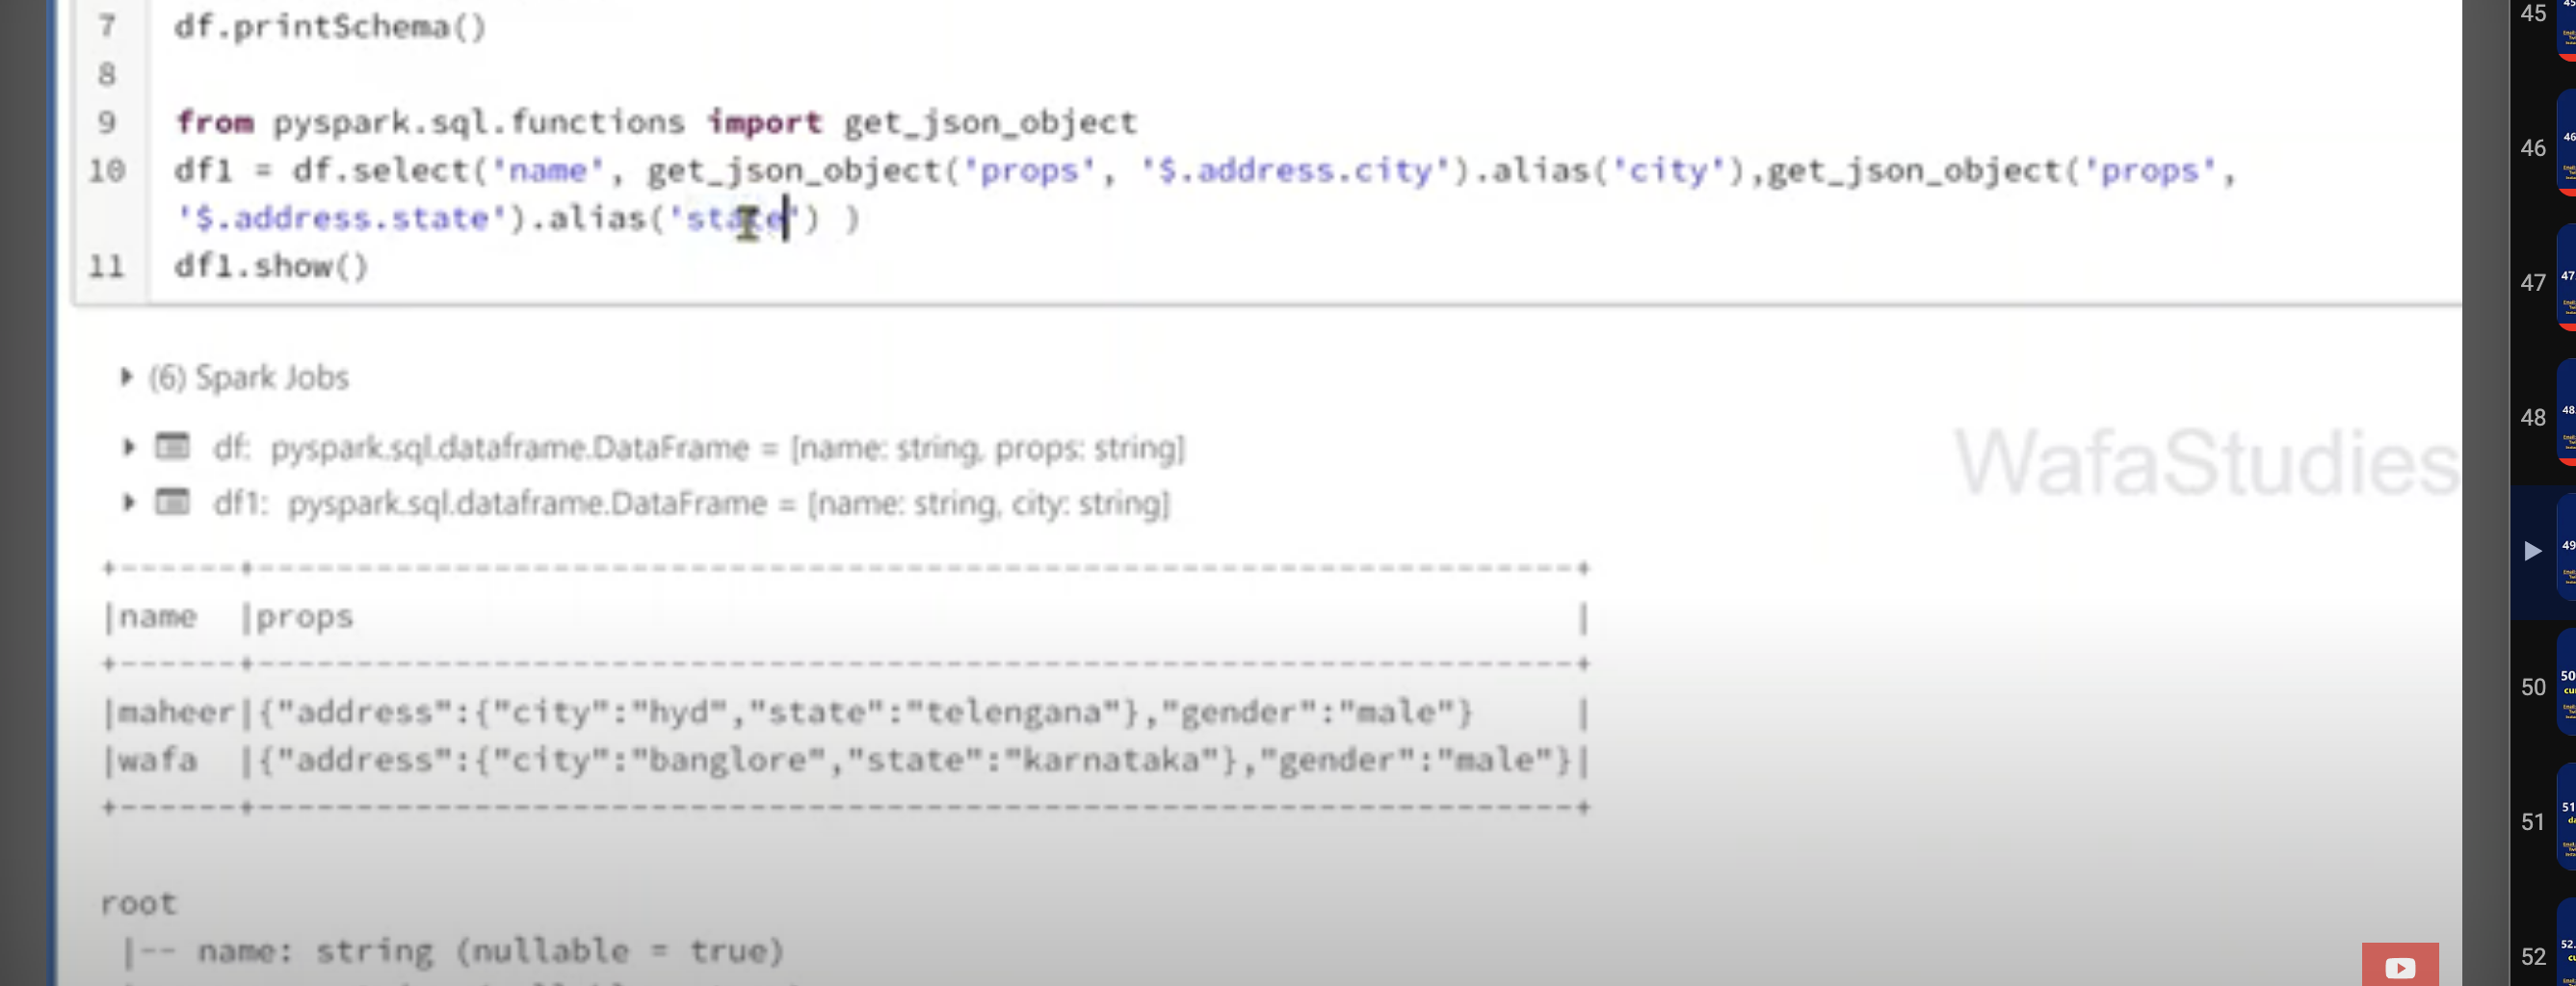